In [ ]:
%load_ext autoreload
%autoreload 2

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from matplotlib import pyplot as plt
import networkx as nx
import torch

### Phase 0

In [21]:
cora_dataset = Planetoid(root='data', name='Cora')
data = cora_dataset[0]
data.to("cuda")
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

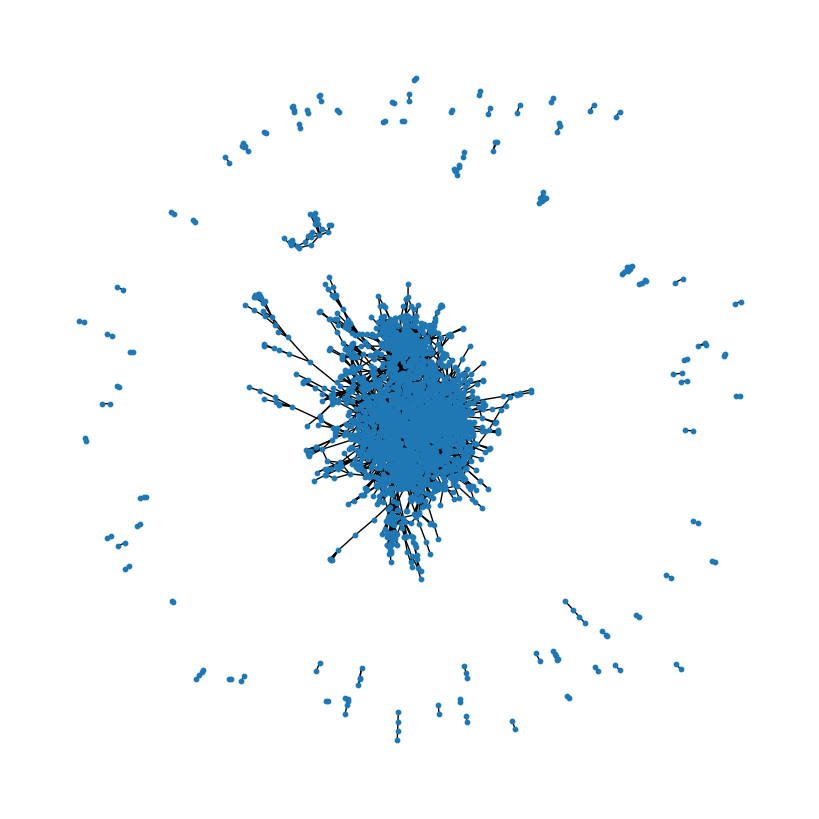

In [ ]:
graph = to_networkx(data, to_undirected=True)

plt.figure(figsize=(8, 8))
nx.draw(graph, node_size=10)
plt.show()

### Phase 1

  2%|▏         | 4/200 [00:00<00:10, 18.67it/s]

Epoch: 0, Train Loss: 1.9484158754348755, Val Loss: 1.95376718044281


 26%|██▋       | 53/200 [00:02<00:07, 19.13it/s]

Epoch: 50, Train Loss: 0.2889818847179413, Val Loss: 0.7443403601646423


 44%|████▍     | 88/200 [00:04<00:05, 18.91it/s]


Early stopping at epoch 88
Training complete. Best validation loss: 0.6370812058448792


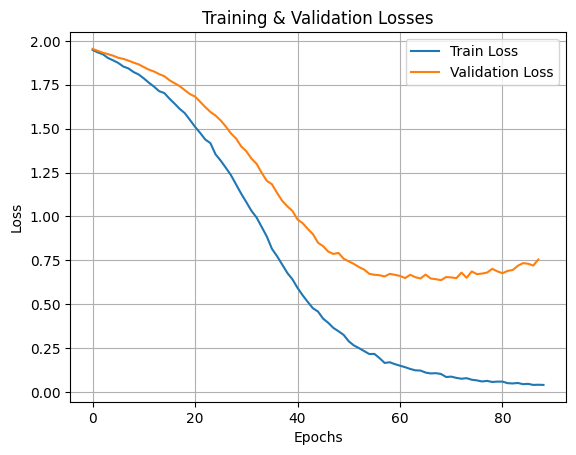

Classification Report:
               precision    recall  f1-score   support

           0      0.662     0.754     0.705       130
           1      0.730     0.890     0.802        91
           2      0.903     0.910     0.907       144
           3      0.923     0.718     0.808       319
           4      0.766     0.879     0.819       149
           5      0.781     0.796     0.788       103
           6      0.736     0.828     0.779        64

    accuracy                          0.805      1000
   macro avg      0.786     0.825     0.801      1000
weighted avg      0.819     0.805     0.806      1000



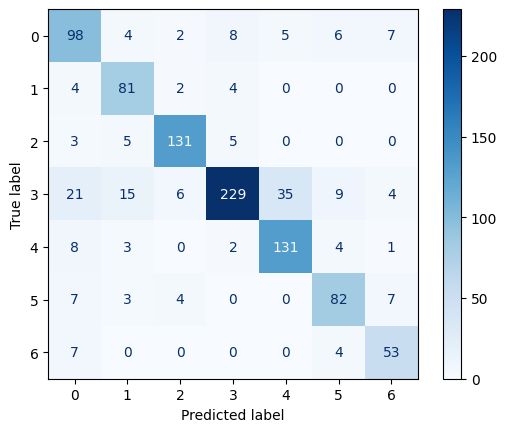

In [28]:
from train import main

hyperparameters = {
    "learning_rate": 0.0001,
    "weight_decay": 5e-4,
    "epochs": 200,
    "log_interval": 50,
    "layers": [2048, 1024, 512],
    "dropout": 0.5,
    "patience": 20,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
main(hyperparameters)